# Assistente Técnico para Edifícios Verdes e Net Zero de Água e Energia
### Sistema RAG com LLM local e citação de fontes

**Desafio:** construir, do zero, um assistente técnico especializado em **Edifícios Verdes e Net Zero de Energia e Água**, capaz de responder perguntas técnicas com precisão e **citando sempre a fonte** que embasou a resposta, tudo executável **localmente**, sem APIs externas pagas.

Este notebook percorre as 8 etapas do desafio:

| Etapa | Conteúdo |
|---|---|
| 1 | Planejamento e escopo (justificativa das tecnologias) |
| 2 | Construção do corpus (12 documentos, 3 categorias) |
| 3 | Limpeza e normalização |
| 4 | Segmentação (chunking) |
| 5 | Embeddings e indexação (ChromaDB) |
| 6 | Pipeline RAG com LLM local (Ollama) |
| 7 | Avaliação (10 perguntas + RAG vs LLM puro) |
| 8 | Relatório crítico + visualização t-SNE |

> A lógica do pipeline está em módulos reutilizáveis em `src/` (importados abaixo); o notebook documenta e executa cada etapa mostrando as saídas reais.


## Etapa 1 — Planejamento e escopo

**Recorte temático.** O título do desafio é *"edifícios eficientes quanto a água e energia"*, e o enunciado pede que as documentações orientem como **coletar e tratar água localmente** e **gerar energia** (fotovoltaica ou outra), de modo que o edifício supra metade ou toda a sua demanda. Por isso o recorte adotado é **abrangente: Energia + Água + Certificações**, tratando as certificações como eixo transversal que conecta os dois temas. Cada documento é rotulado com a subcategoria `energia`, `agua` ou `ambos`.

**Justificativa das escolhas de tecnologia**

- **Modelo de embedding: `intfloat/multilingual-e5-base` (open-source).**
  Modelo multilíngue treinado com objetivo contrastivo, com bom desempenho em **português técnico** e dimensão de 768. É leve o suficiente para rodar em **CPU** (importante para reprodutibilidade local) e usa os prefixos `query:` / `passage:`, que separam a representação da pergunta e do trecho. Alternativas mais pesadas (e5-large, BGE-M3) dariam ganho marginal a um custo de memória/tempo maior, e ficam como melhoria futura.

- **Banco vetorial: `ChromaDB`.**
  Tem **persistência em disco**, API simples e, principalmente, **filtro nativo por metadados** (`where=`), que o enunciado pede para habilitar busca por categoria. Comparado ao FAISS (que indexa vetores mas não guarda metadados nem persiste sozinho), o ChromaDB reduz o código de cola. Usamos métrica de **cosseno** com embeddings normalizados.

- **LLM local: `Qwen2.5 3B` via `Ollama` (quantizado Q4).**
  Modelo pequeno (aceito pelo enunciado), forte em multilíngue/português e que roda em CPU/GPU modesta. O **Ollama** expõe uma API local em `127.0.0.1:11434`, dispensando qualquer serviço pago. O sistema fica 100% **auditável e offline**.

**Arquitetura do pipeline**

```
PDFs/HTML  ->  extração + limpeza  ->  chunking (512 a 1024 tokens)
                                              |
                                   embeddings (e5-base)
                                              |
                                   ChromaDB (vetor + metadados)
                                              |
   pergunta  ->  embedding  ->  busca top-k (filtro por categoria)
                                              |
                       contexto numerado  ->  LLM (Qwen2.5 3B)
                                              |
                          resposta + CITAÇÃO das fontes
```


In [1]:
import sys, json
from pathlib import Path
import pandas as pd

cwd = Path.cwd()
PROJ = cwd.parent if cwd.name == "notebooks" else cwd
sys.path.insert(0, str(PROJ))

from src import corpus_io, textproc, chunking
from src import embeddings_index as eidx
from src import rag

RAW     = PROJ / "corpus" / "raw"
META    = PROJ / "corpus" / "meta"
PROC    = PROJ / "data" / "processed"
CHROMA  = PROJ / "data" / "chroma"
REPORTS = PROJ / "reports"
for d in (RAW, META, PROC, CHROMA, REPORTS):
    d.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 60)
print("Projeto:", PROJ)
print("LLM (Ollama) pronto:", rag.ollama_ready())
print("Modelo de embedding:", eidx.EMBED_MODEL)


Projeto: C:\Users\luizh\OneDrive\Área de Trabalho\gs-edificios-verdes
LLM (Ollama) pronto: True
Modelo de embedding: intfloat/multilingual-e5-base


## Etapa 2 — Construção do corpus

Foram reunidos **12 documentos técnicos** (acima do mínimo de 10), todos **abertos e gratuitos**, cobrindo as **3 categorias** exigidas e os **2 eixos** (energia/água):

- **Normas / guias de certificação:** Guia CBIC de conservação de água, Guia CBIC da ABNT NBR 15575, GBC Brasil Casa, INI-C (Inmetro/Portaria 309/2022).
- **Relatórios técnico-científicos:** CBCS, CNI, Atlas da Eficiência Energética (EPE), artigo sobre águas cinzas.
- **Manuais de tecnologias habilitadoras:** Manual de Engenharia FV (CRESESB), Conservação e Reúso de Água (FIESP/ANA), Reúso no setor industrial (ANA), Cadernos ANEEL de micro/minigeração.

> O texto integral da **ABNT NBR 15575** e o **guia LEED completo** são pagos; foram substituídos por equivalentes gratuitos (Guia CBIC e GBC Brasil Casa). Cada documento tem metadados: fonte, categoria, subcategoria, ano e vigência.


In [2]:
manifest = corpus_io.load_manifest(META / "manifest.json")
df = pd.DataFrame(manifest)[["id", "fonte", "categoria", "subcategoria", "ano", "vigencia"]]
print(f"Total de documentos no manifest: {len(manifest)}\n")
display(df)

print("\nDistribuição por categoria:")
print(df["categoria"].value_counts().to_string())
print("\nDistribuição por subcategoria (eixo):")
print(df["subcategoria"].value_counts().to_string())


Total de documentos no manifest: 12



,id,fonte,categoria,subcategoria,ano,vigencia
0,cresesb-manual-fv-2014,CRESESB/CEPEL/Eletrobras,manual_tecnologia,energia,2014,vigente
1,fiesp-ana-reuso-edificacoes,FIESP/ANA/SindusCon-SP/COMASP,manual_tecnologia,agua,2005,historico
2,ana-reuso-industrial-v1,ANA/FIESP/SindusCon-SP,manual_tecnologia,agua,2004,historico
3,cbic-guia-conservacao-agua,CBIC,norma_certificacao,agua,2019,vigente
4,cbic-guia-nbr15575,CBIC (via Wayback Machine),norma_certificacao,ambos,2017,vigente
5,gbc-brasil-casa-2017,GBC Brasil,norma_certificacao,ambos,2017,vigente
6,inmetro-ini-c-2022,INMETRO/PBE Edifica/PROCEL,norma_certificacao,energia,2022,vigente
7,aneel-caderno-microminigeracao,ANEEL (via Wayback Machine),manual_tecnologia,energia,2016,parcialmente historico
8,cbcs-aspectos-construcao-sustentavel,CBCS/MMA/PNUMA,relatorio_tecnico,ambos,2014,historico
9,cni-uso-racional-agua-industrial,CNI - Confederacao Nacional da Industria,relatorio_tecnico,agua,2017,vigente



Distribuição por categoria:
categoria
manual_tecnologia     4
norma_certificacao    4
relatorio_tecnico     4

Distribuição por subcategoria (eixo):
subcategoria
agua       5
energia    4
ambos      3


In [3]:
# Download idempotente (pula os que já estão em corpus/raw)
corpus_io.download_manifest(manifest, RAW)


[OK ] cresesb-manual-fv-2014        17176.8 KB  
[OK ] fiesp-ana-reuso-edificacoes    1372.1 KB  
[OK ] ana-reuso-industrial-v1         919.6 KB  
[OK ] cbic-guia-conservacao-agua    13560.8 KB  
[OK ] cbic-guia-nbr15575            56253.3 KB  
[OK ] gbc-brasil-casa-2017           8052.5 KB  
[OK ] inmetro-ini-c-2022             2015.8 KB  
[OK ] aneel-caderno-microminigeracao    644.4 KB  
[OK ] cbcs-aspectos-construcao-sustentavel   1124.5 KB  
[OK ] cni-uso-racional-agua-industrial   4205.2 KB  
[OK ] epe-atlas-eficiencia-2021     14528.0 KB  
[OK ] artigo-aguas-cinzas-multifamiliar    795.1 KB  

12/12 documentos baixados.


[{'id': 'cresesb-manual-fv-2014',
  'titulo': 'Manual de Engenharia para Sistemas Fotovoltaicos',
  'fonte': 'CRESESB/CEPEL/Eletrobras',
  'categoria': 'manual_tecnologia',
  'subcategoria': 'energia',
  'ano': 2014,
  'vigencia': 'vigente',
  'tipo': 'pdf',
  'url': 'https://www.cresesb.cepel.br/publicacoes/download/Manual_de_Engenharia_FV_2014.pdf',
  'insecure': True,
  'verified': True,
  'notas': 'Manual de referencia nacional p/ projeto FV (~17,6 MB). Host com certificado TLS de nome incorreto: download com verificacao de cert desativada (insecure).',
  'local_path': 'C:\\Users\\luizh\\OneDrive\\Área de Trabalho\\gs-edificios-verdes\\corpus\\raw\\cresesb-manual-fv-2014.pdf',
  'downloaded': True,
  'bytes': 17589021,
  'error': ''},
 {'id': 'fiesp-ana-reuso-edificacoes',
  'titulo': 'Conservacao e Reuso de Agua em Edificacoes',
  'fonte': 'FIESP/ANA/SindusCon-SP/COMASP',
  'categoria': 'manual_tecnologia',
  'subcategoria': 'agua',
  'ano': 2005,
  'vigencia': 'historico',
  'tip

## Etapa 3 — Limpeza e normalização

Para cada documento (`src/textproc.py`):
1. **Extração** do texto (pdfplumber p/ PDF; também DOCX/HTML/TXT).
2. **Remoção de ruído**: cabeçalhos/rodapés que se repetem na maioria das páginas e números de página; a seção final de *Referências/Bibliografia* (de forma conservadora, só quando aparece no terço final).
3. **Normalização**: conserto de encoding (ftfy), Unicode (NFKC), junção de palavras hifenizadas na quebra de linha e colapso de espaços.
4. **Preservação**: blocos *estruturados* (tabelas de parâmetros, listas e **requisitos numerados**) mantêm suas quebras de linha; só a prosa tem as linhas de diagramação unidas em parágrafos, para não fragmentar requisitos normativos.


In [4]:
docs = []
for item in manifest:
    fp = next(iter(RAW.glob(item["id"] + ".*")), None)
    if fp is None:
        print("[faltando]", item["id"]); continue
    res = textproc.extract_and_clean(fp)
    for k in ("id", "titulo", "fonte", "categoria", "subcategoria", "ano", "vigencia", "url"):
        res[k] = item[k]
    (PROC / (item["id"] + ".txt")).write_text(res["text"], encoding="utf-8")
    docs.append(res)

clean_df = pd.DataFrame([{
    "id": d["id"], "paginas": d["n_pages"],
    "chars_brutos": d["n_chars_raw"], "chars_limpos": d["n_chars_clean"],
    "linhas_cabecalho_removidas": len(d["removed_headers"]),
} for d in docs])
print(f"{len(docs)} documentos processados.\n")
display(clean_df)


12 documentos processados.



,id,paginas,chars_brutos,chars_limpos,linhas_cabecalho_removidas
0,cresesb-manual-fv-2014,530,981213,877207,1
1,fiesp-ana-reuso-edificacoes,152,239224,238939,0
2,ana-reuso-industrial-v1,90,178148,172920,2
3,cbic-guia-conservacao-agua,160,240568,210405,1
4,cbic-guia-nbr15575,311,448386,441824,1
5,gbc-brasil-casa-2017,401,699057,699729,0
6,inmetro-ini-c-2022,124,312576,312754,0
7,aneel-caderno-microminigeracao,32,34388,34372,1
8,cbcs-aspectos-construcao-sustentavel,12,14358,13193,3
9,cni-uso-racional-agua-industrial,240,308283,273206,1


In [5]:
# Amostra do texto limpo de um documento (primeiros 900 caracteres)
amostra = next(d for d in docs if d["id"] == "cresesb-manual-fv-2014")
print(f"--- {amostra['titulo']} ---\n")
print(amostra["text"][:900])


--- Manual de Engenharia para Sistemas Fotovoltaicos ---

Manual de Engenharia para Sistemas Fotovoltaicos

Manual de Engenharia para Sistemas Fotovoltaicos Organizadores: João Tavares Pinho Marco Antonio Galdino CEPEL – CRESESB Edição Revisada e Atualizada Rio de Janeiro – Março – 2014

COORDENAÇÃO E ORGANIZAÇÃO DESTA EDIÇÃO João Tavares Pinho - UFPA João Tavares Pinho - UFPA Marco Antonio Galdino - Cepel José Geraldo de M. Furtado - Cepel Leonardo dos Santos R. Vieira - Cepel ELABORAÇÃO: Lucas Rafael do Nascimento - UFSC Adriano Moehlecke - PUC-RS Luis Carlos Macedo Blasques - UFPA Alexandre de Albuquerque Montenegro - UFSC Marcia da Rocha Ramos - Cepel Alexandre José Bühler - UFRGS Marco Antonio Galdino - Cepel Ana Paula Cardoso Guimarães - Cepel Marcos André Barros Galhardo - UFPA André Ricardo Mocelin - USP Maria das Graças Pimentel de Figueiredo – CBEM Arno Krenzinger - UFRGS Marta Maria de Almeida Olivieri - Cepel Ary Vaz Pinto Junior - 


## Etapa 4 — Segmentação (chunking)

Segmentação semântica (`src/chunking.py`) com alvo de **512 a 1024 tokens** (contados com `tiktoken`, como aproximação independente do tokenizer do modelo). Os chunks **quebram nos títulos** (Capítulo, Seção, Art. N, Crédito N, títulos numerados, linhas em CAIXA ALTA) para não cortar uma seção/artigo/crédito ao meio, e **nunca fragmentam um bloco** (parágrafo, tabela ou lista); só dividem por frases um bloco que sozinho exceda o limite.


In [6]:
all_chunks = []
for d in docs:
    meta = {
        "doc_id": d["id"], "titulo": d["titulo"], "fonte": d["fonte"],
        "categoria": d["categoria"], "subcategoria": d["subcategoria"],
        "ano": str(d["ano"]), "vigencia": d["vigencia"], "url": d["url"],
    }
    all_chunks += chunking.chunk_document(d["text"], meta)

report = chunking.build_chunk_report(all_chunks)
(REPORTS / "chunk_report.json").write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")

with open(PROC / "chunks.jsonl", "w", encoding="utf-8") as f:
    for c in all_chunks:
        f.write(json.dumps(c, ensure_ascii=False) + "\n")

print("RELATÓRIO DE CHUNKING")
print(json.dumps(report, ensure_ascii=False, indent=2))


RELATÓRIO DE CHUNKING
{
  "total_chunks": 1331,
  "tokens_medio": 733.3,
  "tokens_min": 12,
  "tokens_max": 3091,
  "por_categoria": {
    "manual_tecnologia": 528,
    "norma_certificacao": 674,
    "relatorio_tecnico": 129
  },
  "por_subcategoria": {
    "energia": 486,
    "agua": 372,
    "ambos": 473
  },
  "por_documento": {
    "cresesb-manual-fv-2014": 351,
    "fiesp-ana-reuso-edificacoes": 97,
    "ana-reuso-industrial-v1": 67,
    "cbic-guia-conservacao-agua": 87,
    "cbic-guia-nbr15575": 186,
    "gbc-brasil-casa-2017": 280,
    "inmetro-ini-c-2022": 121,
    "aneel-caderno-microminigeracao": 13,
    "cbcs-aspectos-construcao-sustentavel": 7,
    "cni-uso-racional-agua-industrial": 100,
    "epe-atlas-eficiencia-2021": 1,
    "artigo-aguas-cinzas-multifamiliar": 21
  }
}


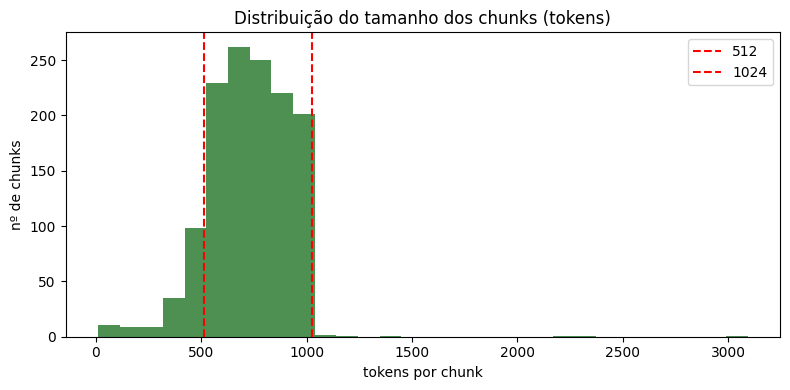

In [7]:
import matplotlib.pyplot as plt
toks = [c["n_tokens"] for c in all_chunks]
plt.figure(figsize=(8, 4))
plt.hist(toks, bins=30, color="#2e7d32", alpha=0.85)
plt.axvline(512, color="red", ls="--", label="512")
plt.axvline(1024, color="red", ls="--", label="1024")
plt.title("Distribuição do tamanho dos chunks (tokens)")
plt.xlabel("tokens por chunk"); plt.ylabel("nº de chunks"); plt.legend()
plt.tight_layout(); plt.savefig(REPORTS / "hist_tokens.png", dpi=110); plt.show()


In [8]:
# Exemplo de um chunk com seus metadados
ex = all_chunks[len(all_chunks) // 2]
print("chunk_id:", ex["chunk_id"], "| tokens:", ex["n_tokens"])
print("fonte:", ex["fonte"], "| categoria:", ex["categoria"], "| seção:", ex["section"])
print("-" * 70)
print(ex["text"][:700])


chunk_id: cbic-guia-nbr15575::063 | tokens: 821
fonte: CBIC (via Wayback Machine) | categoria: norma_certificacao | seção: BRASÍLIA | 2013
----------------------------------------------------------------------
SEGURANÇA CONTRA INCÊNDIO
Os métodos de ensaio de reação ao fogo utilizados como base da avaliação dos ma-
Os ensaios para avaliação dos materiais devem considerar a maneira como são
-
bustível, este deve ser incluído no ensaio. Caso o material seja aplicado a um
substrato incombustível, o ensaio pode ser realizado ultilizando-se substrato
(Fonte: Tabela 3, página 10 da NBR 15575 – Parte 3; Tabela 10, página 20 da NBR 15575 - Parte 4 e Tabela 2, página 14
NBR 15575 – Parte 5)
Método de ensaio
Classe
ISO 1182 EN 13823 ISO 11925-2 (exp. = 30 s)
Incombustível
ΔT ≤ 30 °C;
I - -
Δm ≤ 50 %;
t ≤ 10 s
f
FIGRA ≤ 120 W/s
A Combustível LSF < canto do corpo de prova FS ≤ 150 mm em 60 s
THR600s ≤ 7,5 MJ



## Etapa 5 — Geração de embeddings e indexação (ChromaDB)

Geramos embeddings de **todos os chunks** com o `multilingual-e5-base` (prefixo `passage:`) e indexamos no **ChromaDB persistente** (`data/chroma`), com **métrica de cosseno** e os **metadados** de cada chunk gravados junto ao vetor, o que habilita o **filtro por categoria/subcategoria** na busca.


In [9]:
col = eidx.build_index(all_chunks, CHROMA, reset=True)
print("Chunks indexados no ChromaDB:", col.count())


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/84 [00:00<?, ?it/s]

Chunks indexados no ChromaDB: 1331


## Etapa 6 — Pipeline RAG com LLM local

A busca recupera os *top-k* trechos, que viram um **CONTEXTO numerado**. O **prompt de sistema** (abaixo) obriga o modelo a responder **somente** com base nesses trechos e a **citar a fonte** de cada informação com o número entre colchetes; se a resposta não estiver no contexto, ele deve dizer que *"a informação não está no corpus consultado"*.


In [10]:
print(rag.SYSTEM_RAG)

Você é um assistente técnico especializado em edifícios verdes e Net Zero de água e energia.
Responda EXCLUSIVAMENTE com base nos trechos numerados fornecidos no CONTEXTO.

Regras obrigatórias:
1. Use apenas informações presentes no CONTEXTO; não recorra a conhecimento próprio.
2. Para CADA afirmação técnica, cite a fonte com o número do trecho entre colchetes, ex.: [2].
3. Se a resposta não estiver no CONTEXTO, responda exatamente: "A informação não está no corpus consultado." — e não invente nada.
4. Seja objetivo e técnico, em português. Reproduza valores, normas e parâmetros exatamente como aparecem no trecho.



In [11]:
out = rag.answer_rag(col, "Quais sistemas um edifício pode usar para reduzir o consumo de água potável?", k=5)
print("PERGUNTA:", out["question"], "\n")
print("RESPOSTA:\n", out["answer"], "\n")
print("FONTES RECUPERADAS:")
for s in out["sources"]:
    print(f"  [{s['n']}] {s['fonte']} — {s['titulo']} ({s['ano']}) | score={s['score']} | {s['categoria']}/{s['subcategoria']}")


PERGUNTA: Quais sistemas um edifício pode usar para reduzir o consumo de água potável? 

RESPOSTA:
 [4] [5] Um edifício pode usar diferentes sistemas para reduzir o consumo de água potável, incluindo a instalação de um sistema de irrigação de alta eficiência conforme mencionado em [5], e também a utilização de vegetação apropriada e projetos adequados do sistema de irrigação eficiente conforme descrito em [4]. Além disso, o uso de zonas múltiplas de irrigação pode ser implementado para reduzir o desperdício de água conforme sugerido em [2]. 

FONTES RECUPERADAS:
  [1] FIESP/ANA/SindusCon-SP/COMASP — Conservacao e Reuso de Agua em Edificacoes (2005) | score=0.868 | manual_tecnologia/agua
  [2] CBIC — Guia Orientativo sobre Normas de Conservacao de Agua (2019) | score=0.861 | norma_certificacao/agua
  [3] FIESP/ANA/SindusCon-SP/COMASP — Conservacao e Reuso de Agua em Edificacoes (2005) | score=0.861 | manual_tecnologia/agua
  [4] FIESP/ANA/SindusCon-SP/COMASP — Conservacao e Reuso de Agu

In [12]:
# Busca com FILTRO por metadados (só documentos do eixo 'energia')
out_f = rag.answer_rag(col, "Como funciona a compensação de energia da micro e minigeração distribuída?",
                       k=5, where={"subcategoria": "energia"})
print(out_f["answer"], "\n")
print("Fontes (todas do eixo energia):")
for s in out_f["sources"]:
    print(f"  [{s['n']}] {s['fonte']} — {s['subcategoria']}")


[4] A compensação de energia na micro e minigeração distribuída funciona através do Sistema de Compensação de Energia Elétrica (SCEE). Este sistema permite que a energia excedente gerada pela unidade consumidora com micro ou minigeração seja injetada na rede da distribuidora, a qual funcionará como uma bateria, armazenando esse excedente até o momento em que a unidade consumidora necessite de energia proveniente da distribuidora. Dessa forma, a energia elétrica gerada por essas unidades consumidoras é cedida à distribuidora local, sendo posteriormente compensada com o consumo de energia elétrica dessa mesma unidade consumidora (ou de outra unidade consumidora de mesmo titularidade). 

Fontes (todas do eixo energia):
  [1] ANEEL (via Wayback Machine) — energia
  [2] CRESESB/CEPEL/Eletrobras — energia
  [3] ANEEL (via Wayback Machine) — energia
  [4] ANEEL (via Wayback Machine) — energia
  [5] CRESESB/CEPEL/Eletrobras — energia


## Etapa 7 — Avaliação do sistema

**10 perguntas técnicas** sobre o corpus. Para cada uma registramos a resposta do RAG e as **fontes citadas**. Incluímos propositalmente 2 perguntas **fora da cobertura** do corpus (ex.: limiares específicos do LEED, preços de mercado) para verificar se o sistema **admite a ausência** em vez de alucinar. Isso alimenta a métrica de *cobertura* do relatório. Em seguida, comparamos **3 respostas** com o **mesmo LLM sem RAG**.


In [13]:
PERGUNTAS = [
    {"q": "Quais usos não potáveis são indicados para o reúso de águas cinzas em edificações?", "comparar": True},
    {"q": "Como funciona o sistema de compensação de energia elétrica na micro e minigeração distribuída?", "comparar": True},
    {"q": "Que parâmetros o INI-C utiliza para avaliar a eficiência energética da envoltória de edificações comerciais?", "comparar": True},
    {"q": "Quais são os principais componentes de um sistema fotovoltaico conectado à rede?", "comparar": False},
    {"q": "Quais medidas de conservação de água são recomendadas para reduzir o consumo em edificações?", "comparar": False},
    {"q": "O que a certificação GBC Brasil Casa avalia em relação ao uso da água e da energia?", "comparar": False},
    {"q": "Como o guia da CBIC trata o desempenho dos sistemas hidrossanitários segundo a NBR 15575?", "comparar": False},
    {"q": "Quais indicadores de eficiência energética o Atlas da Eficiência Energética da EPE acompanha?", "comparar": False},
    # Fora da cobertura (esperado: 'não está no corpus'):
    {"q": "Qual é o limiar exato de pontos do crédito de eficiência hídrica da certificação LEED v4.1 BD+C?", "comparar": False},
    {"q": "Qual o custo médio, em reais por kWp, de um sistema fotovoltaico residencial instalado no Brasil em 2024?", "comparar": False},
]

SENTINELA = "não está no corpus"
resultados = []
for i, p in enumerate(PERGUNTAS, 1):
    r = rag.answer_rag(col, p["q"], k=5)
    coberta = SENTINELA.lower() not in r["answer"].lower()
    resultados.append({
        "n": i, "pergunta": p["q"], "coberta": coberta,
        "resposta": r["answer"],
        "fontes": [f"[{s['n']}] {s['fonte']} — {s['titulo']}" for s in r["sources"]],
        "fonte_top": f"{r['sources'][0]['fonte']} ({r['sources'][0]['score']})" if r["sources"] else "",
    })
    print(f"\n{'='*78}\nQ{i}. {p['q']}\n{'-'*78}")
    print(r["answer"])
    print("Fontes:", " ; ".join(s for s in resultados[-1]["fontes"][:3]))

cobertas = sum(1 for r in resultados if r["coberta"])
print(f"\n\nCOBERTURA: {cobertas}/{len(PERGUNTAS)} perguntas respondidas com base no corpus.")
(REPORTS / "avaliacao.json").write_text(json.dumps(resultados, ensure_ascii=False, indent=2), encoding="utf-8")



Q1. Quais usos não potáveis são indicados para o reúso de águas cinzas em edificações?
------------------------------------------------------------------------------
[3] [4] Os principais usos não potáveis indicados para o reúso de águas cinzas em edificações são descargas de vasos sanitários, lavagem de pisos, lavagem de roupas e lavagem de veículos, conforme estabelecido na tabela 1 do Manual da FIESP (2005) e no item 5.6.4 da NBR 13.969/97 (ABNT, 1997).
Fontes: [1] FIESP/ANA/SindusCon-SP/COMASP — Conservacao e Reuso de Agua em Edificacoes ; [2] Maccarini, Cauduro & Silva (UNESC/UFRGS) — O Uso de Aguas Cinzas em uma Edificacao Multifamiliar ; [3] FIESP/ANA/SindusCon-SP/COMASP — Conservacao e Reuso de Agua em Edificacoes

Q2. Como funciona o sistema de compensação de energia elétrica na micro e minigeração distribuída?
------------------------------------------------------------------------------
[1] [3] [4] [5]

O Sistema de Compensação de Energia Elétrica (SCE) funciona da seguinte

12974

In [14]:
# Tabela-resumo da avaliação
aval_df = pd.DataFrame([{
    "n": r["n"], "pergunta": r["pergunta"][:55] + "...",
    "coberta": "sim" if r["coberta"] else "não (sem cobertura)",
    "fonte principal": r["fonte_top"],
} for r in resultados])
display(aval_df)


,n,pergunta,coberta,fonte principal
0,1,Quais usos não potáveis são indicados para o reúso de á...,sim,FIESP/ANA/SindusCon-SP/COMASP (0.889)
1,2,Como funciona o sistema de compensação de energia elétr...,sim,ANEEL (via Wayback Machine) (0.878)
2,3,Que parâmetros o INI-C utiliza para avaliar a eficiênci...,sim,INMETRO/PBE Edifica/PROCEL (0.87)
3,4,Quais são os principais componentes de um sistema fotov...,sim,CRESESB/CEPEL/Eletrobras (0.862)
4,5,Quais medidas de conservação de água são recomendadas p...,sim,CBIC (0.878)
5,6,O que a certificação GBC Brasil Casa avalia em relação ...,sim,GBC Brasil (0.893)
6,7,Como o guia da CBIC trata o desempenho dos sistemas hid...,sim,CBIC (via Wayback Machine) (0.863)
7,8,Quais indicadores de eficiência energética o Atlas da E...,não (sem cobertura),CBCS/MMA/PNUMA (0.863)
8,9,Qual é o limiar exato de pontos do crédito de eficiênci...,não (sem cobertura),GBC Brasil (0.859)
9,10,"Qual o custo médio, em reais por kWp, de um sistema fot...",não (sem cobertura),GBC Brasil (0.872)


In [15]:
# Comparação RAG vs LLM puro (sem contexto), nas 3 perguntas marcadas
comparacoes = []
for p in [x for x in PERGUNTAS if x["comparar"]]:
    com_rag = rag.answer_rag(col, p["q"], k=5)
    sem_rag = rag.answer_plain(p["q"])
    comparacoes.append({"pergunta": p["q"], "rag": com_rag["answer"],
                        "fontes_rag": [f"[{s['n']}] {s['fonte']}" for s in com_rag["sources"]],
                        "puro": sem_rag["answer"]})
    print(f"\n{'#'*78}\nPERGUNTA: {p['q']}")
    print(f"\n>>> COM RAG (cita fontes):\n{com_rag['answer']}")
    print("Fontes:", " ; ".join(comparacoes[-1]["fontes_rag"][:3]))
    print(f"\n>>> LLM PURO (sem contexto):\n{sem_rag['answer']}")

(REPORTS / "comparacao.json").write_text(json.dumps(comparacoes, ensure_ascii=False, indent=2), encoding="utf-8")



##############################################################################
PERGUNTA: Quais usos não potáveis são indicados para o reúso de águas cinzas em edificações?

>>> COM RAG (cita fontes):
[3] [4] Os principais usos não potáveis indicados para o reúso de águas cinzas em edificações são descargas de vasos sanitários, lavagem de pisos, lavagem de roupas e lavagem de veículos, conforme estabelecido na tabela 1 do Manual da FIESP (2005) e no item 5.6.4 da NBR 13.969/97 (ABNT, 1997).
Fontes: [1] FIESP/ANA/SindusCon-SP/COMASP ; [2] Maccarini, Cauduro & Silva (UNESC/UFRGS) ; [3] FIESP/ANA/SindusCon-SP/COMASP

>>> LLM PURO (sem contexto):
O reuso de águas cinzas (água da chuva ou água de esgoto não contaminada) em edifícios verdes e Net Zero é uma prática cada vez mais comum, mas deve ser aplicada de maneira cuidadosa para evitar uso inapropriado. Aqui estão alguns usos não potáveis indicados:

1. **Reuso na irrigação**: Águas cinzas podem ser utilizadas para irrigar jardins e plan

10059

## Etapa 8 — Visualização t-SNE e relatório crítico

Projeção **t-SNE** dos embeddings dos chunks em 2D, colorida por **categoria** e por **subcategoria**, para inspecionar se trechos do mesmo tipo formam **clusters** coerentes no espaço vetorial.


Matriz de embeddings: (1331, 768)


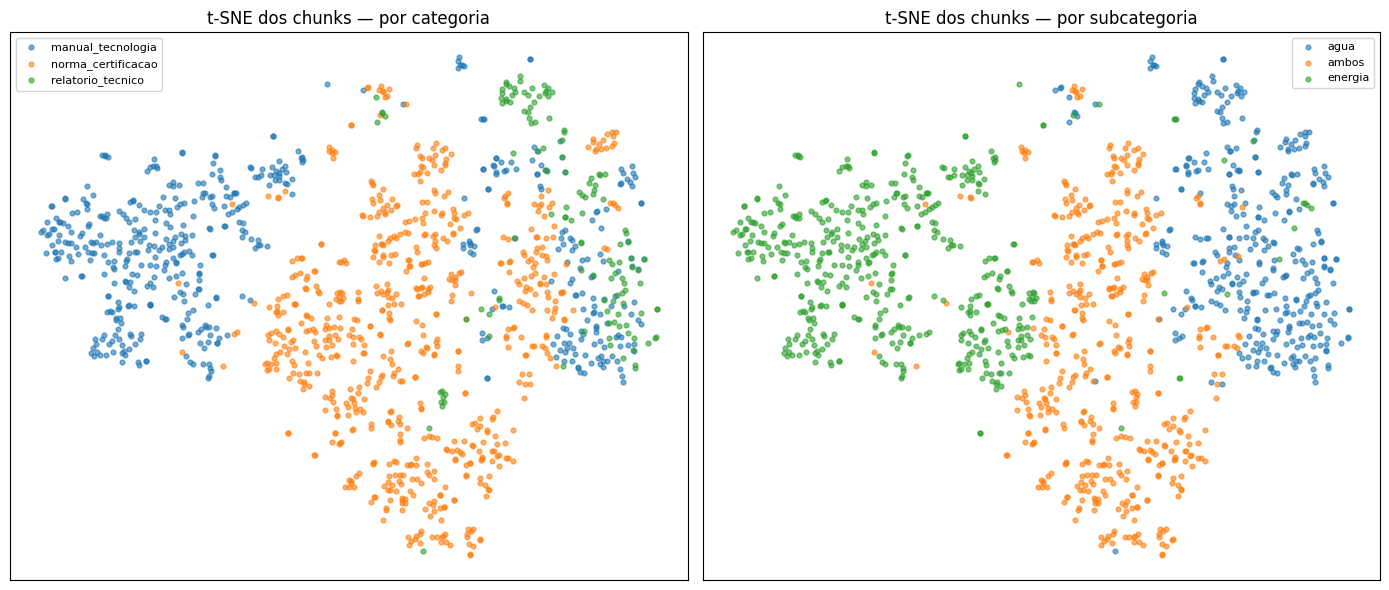

In [16]:
import numpy as np
from sklearn.manifold import TSNE

got = col.get(include=["embeddings", "metadatas"])
X = np.array(got["embeddings"])
cats = [m["categoria"] for m in got["metadatas"]]
subs = [m["subcategoria"] for m in got["metadatas"]]
print("Matriz de embeddings:", X.shape)

perp = min(30, max(5, X.shape[0] // 4))
emb2d = TSNE(n_components=2, perplexity=perp, init="pca", random_state=42).fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, labels, titulo in [(axes[0], cats, "por categoria"), (axes[1], subs, "por subcategoria")]:
    for lab in sorted(set(labels)):
        m = [l == lab for l in labels]
        ax.scatter(emb2d[m, 0], emb2d[m, 1], s=12, alpha=0.6, label=lab)
    ax.set_title(f"t-SNE dos chunks — {titulo}"); ax.legend(fontsize=8); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(REPORTS / "tsne.png", dpi=110); plt.show()


### Relatório crítico

**1. Dificuldades na coleta do corpus.** Reunir fontes técnicas brasileiras abertas exigiu contornar vários obstáculos. (i) O texto integral da **ABNT NBR 15575** e o guia completo do **LEED** são *pagos*; foram substituídos por equivalentes gratuitos e oficiais (o Guia CBIC da NBR 15575 e o GBC Brasil Casa), preservando o rigor técnico sem violar licenças. (ii) Vários links institucionais estavam *mortos ou bloqueados*: a **INI-R** (Portaria 309/2022, residencial) retornou 404 em todas as URLs testadas e foi **removida** do corpus, que ainda mantém 12 documentos (acima do mínimo de 10) e o equilíbrio 4/4/4 entre categorias; o Guia CBIC da NBR 15575 e o Caderno ANEEL caíram (404/403 por WAF) e foram recuperados via **Internet Archive** (capturas status-200). (iii) O host do **Manual CRESESB** apresentava certificado TLS com nome incorreto, exigindo download com verificação de certificado desabilitada (sinalizado como `insecure` no manifest). Todas essas decisões ficaram registradas no campo `notas` do manifest, garantindo rastreabilidade da proveniência.

**2. Dificuldades de extração e impacto na cobertura.** A etapa mais crítica foi a **extração de texto dos PDFs**. O *Atlas da Eficiência Energética da EPE* (14,8 MB, 83 páginas) produziu apenas **859 caracteres** de texto limpo e **um único chunk**: trata-se de um relatório fortemente **imagético/vetorial**, cujos gráficos e tabelas são renderizados como imagem e, portanto, invisíveis ao `pdfplumber`. O relatório do **CBCS** também rendeu pouco (13 KB, 7 chunks). A consequência aparece diretamente na avaliação: a pergunta Q8, sobre os indicadores do Atlas, foi respondida com *"a informação não está no corpus consultado"*. Mas, neste caso, isso ocorreu **não por escolha de escopo, e sim por falha de extração**: o conteúdo existe na fonte, porém nunca chegou ao índice. É uma limitação honesta do pipeline atual. A distribuição de chunks por documento ficou, assim, bastante **desigual** (CRESESB 351, GBC 280, NBR 15575 186, contra CBCS 7 e EPE 1), num total de **1.331 chunks** com média de **733 tokens**, dentro do alvo de 512 a 1024. O `tokens_max` de **3.091** revela um trade-off deliberado: blocos atômicos (parágrafos longos e, sobretudo, **tabelas normativas**) que excedem o limite **não são subdivididos**, para não fragmentar requisitos: preferiu-se preservar a integridade semântica a uniformizar o tamanho.

**3. Qualidade dos clusters (t-SNE).** A projeção por **subcategoria** é o resultado mais eloquente: os chunks de **energia** ocupam a metade esquerda, os de **água** a metade direita e os de tema **misto** o centro, uma separação temática limpa que **valida a escolha do `multilingual-e5-base`**: o espaço vetorial capturou o eixo água/energia mesmo em português técnico, sem treino específico. Já a projeção por **categoria** é mais difusa: os manuais formam um bloco coeso (puxado pelo volumoso manual FV), mas normas e relatórios se sobrepõem, porque o **tipo documental cruza o tema**: uma norma e um relatório sobre água são vizinhos semânticos ainda que de categorias distintas. Ou seja, o modelo agrupa por **assunto**, não por **gênero do documento**, comportamento esperado e desejável para a recuperação.

**4. Proporção de cobertura.** Das 10 perguntas, **7 foram respondidas com base no corpus** e 3 declinadas. Duas declinações eram **propositais** (limiar do crédito hídrico do LEED v4.1 e custo de mercado em R$/kWp): informação fora do escopo documental, e o sistema **admitiu a ausência em vez de alucinar**, exatamente o comportamento desejado. A terceira (Q8) é o gap de extração já discutido. As 7 respostas cobertas citaram **fontes corretas e pertinentes** (águas cinzas: FIESP/ANA mais artigo UNESC; micro/minigeração: ANEEL; FV: CRESESB; INI-C: INMETRO; conservação de água: CBIC; GBC Casa: GBC Brasil), com *scores* de similaridade entre **0,86 e 0,89**.

**5. Impacto do RAG (vs. LLM puro).** A comparação com o mesmo Qwen2.5 3B **sem contexto** foi reveladora. Sem RAG, o modelo **alucinou** sistematicamente: definiu "águas cinzas" erroneamente como *água de chuva* e inventou usos (geração de energia térmica); criou categorias regulatórias inexistentes ("Compensação Direta" vs. "Indireta, Tarifa de Energia Solar"); e, no caso mais grave, **errou o próprio significado da sigla INI-C** ("Índice Nacional de Eficiência Energética"), afirmando que "não é termo técnico usado no Brasil", quando na verdade é a *Instrução Normativa Inmetro*. Com RAG, as mesmas perguntas produziram valores, normas e siglas **corretos e rastreáveis** (RedCgTT, ASHRAE Standard 140, REN ANEEL 482/2012, NBR 13.969/97), cada afirmação ancorada a um trecho `[n]`. O ganho em **precisão, rastreabilidade e ausência de alucinação** é qualitativamente evidente: o RAG não só acerta mais, como permite **auditar** a origem de cada afirmação.

**6. Melhorias futuras.** (a) **OCR** (Tesseract / `ocrmypdf`) na etapa de extração, para resgatar documentos imagéticos como o Atlas da EPE e eliminar o maior gap de cobertura atual. (b) **Reranking** com *cross-encoder* e/ou embeddings maiores (e5-large, BGE-M3) para refinar a recuperação em perguntas cujo *top-k* misturou guias semelhantes (Q7, sobre a NBR 15575, trouxe trechos de dois guias CBIC distintos). (c) **Subdivisão de blocos** acima do limite e um *parser* de tabelas dedicado, reduzindo os chunks de cerca de 3 mil tokens sem quebrar requisitos. (d) **Avaliação automática** de *groundedness/faithfulness* sobre um conjunto maior de perguntas e um leve ajuste do prompt para padronizar o formato das citações `[n]` (a Q6 usou números de seção como marcadores, um desvio cosmético do padrão).


## Conclusão

O sistema entrega um assistente técnico **local, auditável e com citação de fontes**, atendendo às 8 etapas do desafio. A recuperação por similaridade com filtro por metadados, somada a um LLM local com prompt restritivo, garante respostas rastreáveis e a recusa explícita quando a informação não consta no corpus.


## Demonstração interativa

Para consultar o assistente com qualquer pergunta, edite o texto de `pergunta` na célula abaixo e execute (Shift+Enter). A resposta vem com as fontes citadas; perguntas fora do escopo do corpus recebem a mensagem padrão de ausência.


In [26]:
pergunta = "Qual o custo médio, em reais por kWp, de um sistema fotovoltaico residencial instalado no Brasil em 2024?"


resp = rag.answer_rag(col, pergunta, k=5)
print("PERGUNTA:", pergunta, "\n")
print("RESPOSTA:\n", resp["answer"], "\n")
print("FONTES:")
for s in resp["sources"]:
    print(f"  [{s['n']}] {s['fonte']} — {s['titulo']} ({s['ano']})")


PERGUNTA: Qual o custo médio, em reais por kWp, de um sistema fotovoltaico residencial instalado no Brasil em 2024? 

RESPOSTA:
 A informação não está no corpus consultado. 

FONTES:
  [1] GBC Brasil — Guia de Certificacao GBC Brasil Casa (Edicao 2017) (2017)
  [2] CRESESB/CEPEL/Eletrobras — Manual de Engenharia para Sistemas Fotovoltaicos (2014)
  [3] CRESESB/CEPEL/Eletrobras — Manual de Engenharia para Sistemas Fotovoltaicos (2014)
  [4] CRESESB/CEPEL/Eletrobras — Manual de Engenharia para Sistemas Fotovoltaicos (2014)
  [5] CRESESB/CEPEL/Eletrobras — Manual de Engenharia para Sistemas Fotovoltaicos (2014)
